In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
# matplotlib.use("pgf")
# matplotlib.rcParams.update({
#     "pgf.texsystem": "pdflatex",
#     'font.family': 'serif',
#     'text.usetex': True,
#     'pgf.rcfonts': False,
# })
import seaborn as sns
import numpy as np

df = pd.read_csv('randomizer.csv')

print(df.shape)
print(df.head())

(50, 3)
                                        move_history                scores  \
0  [('b', (41, 32), 0), ('r', (18, 25), 0), ('b',...   {'b': -17, 'r': 78}   
1  [('b', (41, 34), 0), ('r', (16, 25), 0), ('b',...    {'b': 40, 'r': -3}   
2  [('b', (45, 36), 0), ('r', (20, 27), 0), ('b',...   {'b': 39, 'r': -17}   
3  [('b', (41, 32), 0), ('r', (18, 25), 0), ('b',...  {'b': -42, 'r': -27}   
4  [('b', (45, 36), 0), ('r', (18, 25), 0), ('b',...   {'b': -67, 'r': 92}   

  winner  
0      r  
1      b  
2      b  
3      r  
4      r  


In [18]:
df['move_history_length'] = df['move_history'].apply(eval).apply(len)
df['red_score'] = [eval(item)['r'] for item in df['scores']]
df['blue_score'] = [eval(item)['b'] for item in df['scores']]
df['winner'] = df['winner'].apply(lambda x: "RED" if x == 'r' else "BLUE" if x == 'b' else "DRAW" if x == 't' else x)
df['score_diff'] = df['red_score'] - df['blue_score']

blue_total_wins = df['winner'].apply(lambda x: 1 if x == 'BLUE' else 0).sum()
red_total_wins = df['winner'].apply(lambda x: 1 if x == 'RED' else 0).sum()
tie_total_wins = df['winner'].apply(lambda x: 1 if x == 'DRAW' else 0).sum()

blue_average_score = df['blue_score'].mean()
red_average_score = df['red_score'].mean()

# Display the average scores
print(f"Average Blue Score: {blue_average_score}")
print(f"Average Red Score: {red_average_score}")

# Display the total wins for each player
print(f"Total Blue Wins: {blue_total_wins}")
print(f"Total Red Wins: {red_total_wins}")
print(f"Total Tie Wins: {tie_total_wins}")

# Display the updated DataFrame with the new column

print(df[['move_history_length', 'red_score', 'blue_score', 'winner', 'score_diff']].head())
df[['move_history_length', 'red_score', 'blue_score', 'winner', 'score_diff']].to_csv('randomizer_updated.csv', index=False)


Average Blue Score: -19.42
Average Red Score: 11.02
Total Blue Wins: 19
Total Red Wins: 31
Total Tie Wins: 0
   move_history_length  red_score  blue_score winner  score_diff
0                   57         78         -17    RED          95
1                   49         -3          40   BLUE         -43
2                   48        -17          39   BLUE         -56
3                   43        -27         -42    RED          15
4                   59         92         -67    RED         159


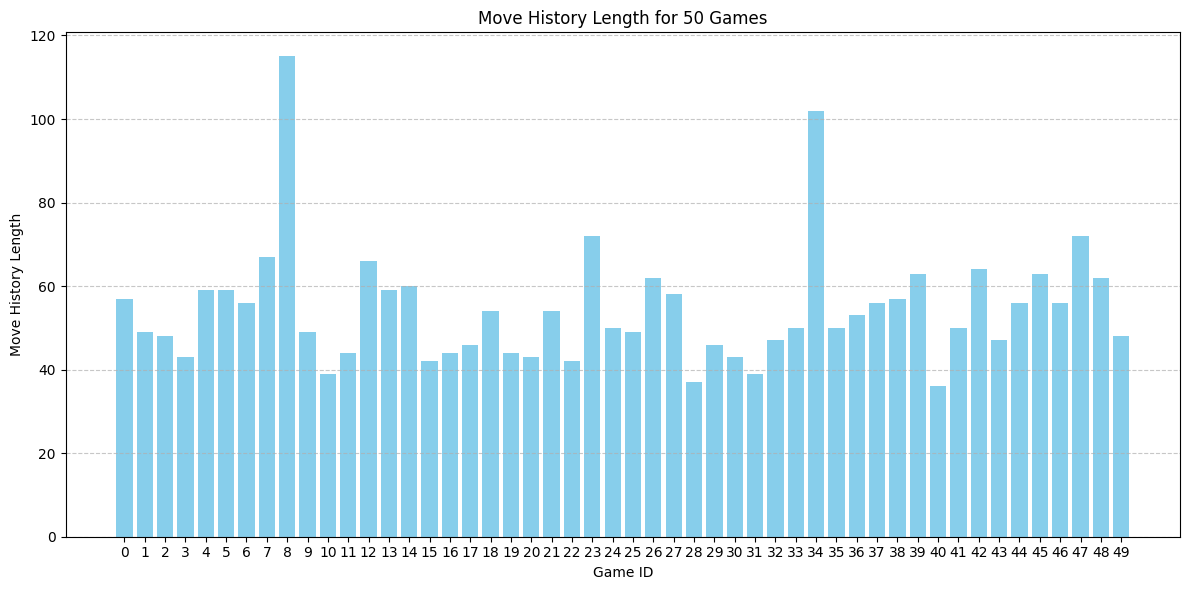

54.54


In [ ]:
# Bar Plot
plt.figure(figsize=(12, 6))
plt.bar(df.index, df['move_history_length'], color='skyblue')
plt.xlabel("Game ID")
plt.ylabel("Move History Length")
plt.title("Move History Length for 50 Games")
plt.xticks(ticks=np.arange(50), labels=np.arange(50))
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('images/randomizer_bar.png', dpi=100)
plt.show()

# Average Score Plot
average_length = df['move_history_length'].mean()
print(average_length)

In [20]:
def get_difflist(history):
    red_score = 0
    blue_score = 0
    difflist = []
    for move in history:
        if move[0] == 'r':
            red_score += move[2]
        elif move[0] == 'b':
            blue_score += move[2]
        difflist.append(red_score - blue_score)
    return difflist

move_history = df['move_history'].apply(eval)
df['move_difflist'] = move_history.apply(get_difflist)
indexer = df['score_diff'].index
for idx in df.loc[indexer].index:
    replacement = int(df.at[idx, 'score_diff'])
    df.at[idx, 'move_difflist'][-1] = replacement

print(df['move_difflist'])
df['move_difflist'].to_csv('randomizer_difflist.csv', index=False)

0     [0, 0, 10, 12, 12, 10, 10, 10, 10, 10, 10, 10,...
1     [0, 0, 13, 13, 4, 4, 4, 4, 4, 4, 4, 9, 9, -4, ...
2     [0, 0, 0, -8, -7, -7, -67, -72, -72, -72, -72,...
3     [0, 0, 10, 12, 12, 12, 12, 12, 12, 12, 12, 12,...
4     [0, 0, 0, -6, -5, -5, -5, -5, -5, -5, -5, -5, ...
5     [0, 0, 0, 24, 22, 22, 22, 22, 22, 22, 5, 5, 15...
6     [0, 0, -2, -2, 4, 4, 4, 4, -32, -41, -41, -41,...
7     [0, 0, 13, 13, 13, 13, 13, 13, 13, 15, 15, 15,...
8     [0, 0, 0, -6, 9, 9, 8, 1, 1, 1, 1, 1, 1, 1, 1,...
9     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, ...
10    [0, 0, -2, -2, 4, 4, 4, 4, 4, 64, 64, 74, 80, ...
11    [0, 0, 0, 36, 33, 33, 33, 33, 33, 33, 33, 33, ...
12    [0, 0, 0, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...
13    [0, 0, 0, 0, 0, 5, 5, 5, -35, -55, -55, -55, -...
14    [0, 0, 0, 0, 0, 0, 0, -6, -7, 14, 14, 23, 33, ...
15    [0, 0, 10, 12, 12, 12, 12, 12, 12, 12, 12, 72,...
16    [0, 0, 0, 0, 6, -4, -4, 2, 2, 2, 2, 26, 33, 33...
17    [0, 0, 13, 13, 4, 4, 4, 4, 4, 3, -9, -11, 

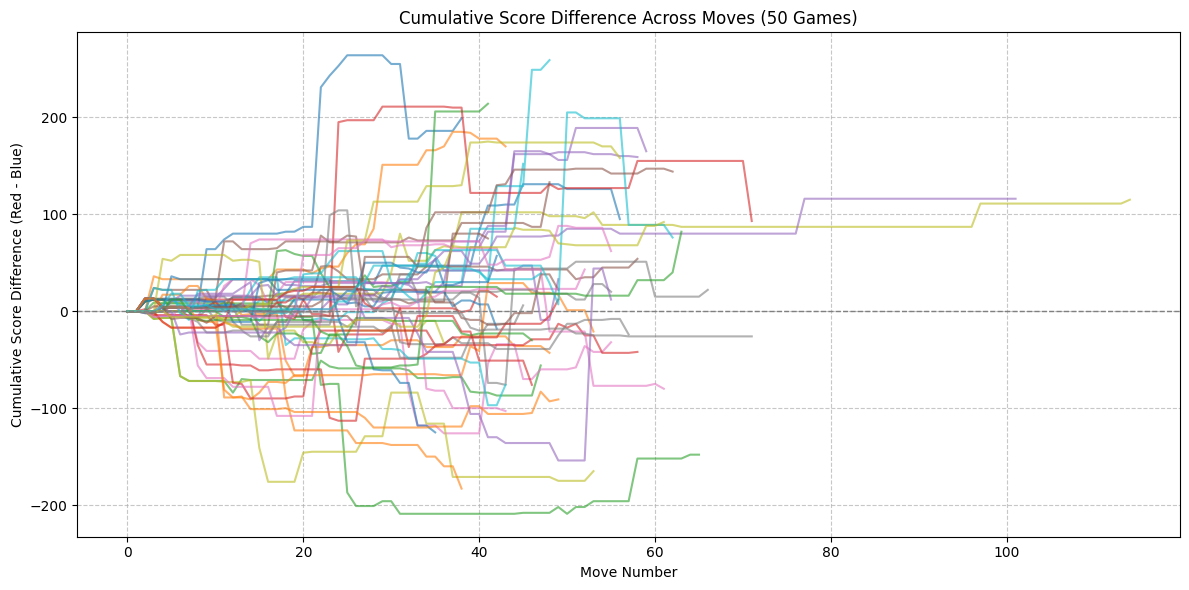

In [ ]:
# Plot each game's cumulative score difference over time
plt.figure(figsize=(12, 6))

for i, row in df.iterrows():
    move_numbers = list(range(len(row["move_difflist"])))
    plt.plot(move_numbers, row["move_difflist"], label=f"Game {i+1}", alpha=0.6)

plt.xlabel("Move Number")
plt.ylabel("Cumulative Score Difference (Red - Blue)")
plt.title("Cumulative Score Difference Across Moves (50 Games)")
plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('images/randomizer_cumuscorediff.png', dpi=100)
plt.show()

red_score     11.02
blue_score   -19.42
dtype: float64
[  78   -3  -17  -27   92   14 -117   -3  100  199   93   95 -191  -29
  113  117 -107  -10  -61  -81   -1  -32  222   53   22  -13 -101  -85
 -113  155   15 -138  -19    5  105    1  -36  -22   46  158  -89  -83
  133   -8    1    8   74  -23   49   12]
[ -17   40   39  -42  -67  -40  -85  -25  -15  -60 -106  -75  -43   13
  -52   42   -4  -16  104   -5   17  -11    8  -40  -11 -146  -21  -61
  -80    3  -42   45   11   -7  -11  -21  -79  -42 -112   82   36    8
   51   68  -11 -136   12    3  -43  -27]


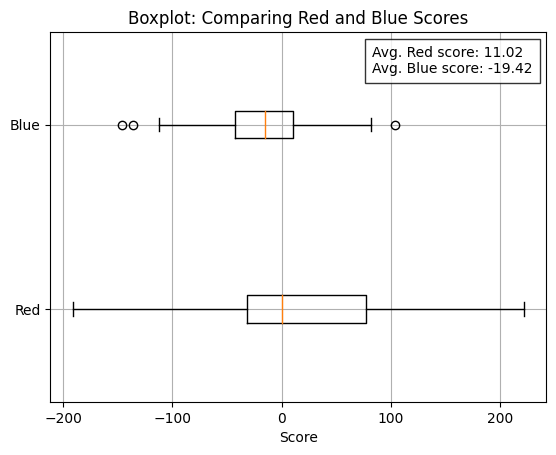

In [ ]:
avg = df[['red_score', 'blue_score']].mean()
print(avg)

red_data = df['red_score'].values
print(red_data)

blue_data = df['blue_score'].values
print(blue_data)

# plt.figure()
# plt.boxplot([red_data, blue_data], vert=False)
# plt.yticks([1, 2], ['Red', 'Blue'])
# plt.title('Boxplot: Score Spread')
# plt.xlabel('Score')
# plt.show()

from matplotlib.offsetbox import AnchoredText

# two datasets

fig, ax = plt.subplots()

# draw boxplots
ax.boxplot([df['red_score'], df['blue_score']], vert=False, labels=['Red','Blue'])

# compute means
mean1 = avg[0]
mean2 = avg[1]

# create an AnchoredText box in upper‑right (loc=1)
txt = AnchoredText(
    f"Avg. Red score: {mean1:.2f}\nAvg. Blue score: {mean2:.2f}",
    loc=1,                # 1=upper‑right
    frameon=True,         # draw the box
    pad=0.5,              # padding in font‑size units
)
# style the box (optional — you get same API as legend frame)
txt.patch.set_facecolor('white')
txt.patch.set_edgecolor('black')
txt.patch.set_alpha(0.8)

ax.add_artist(txt)
ax.set_xlabel('Score')
ax.set_title('Boxplot: Comparing Red and Blue Scores')
plt.grid(True)
plt.savefig('images/randomizer_boxplot.png', dpi=100)
plt.show()


C:\Users\Asus\AppData\Local\Temp\ipykernel_20764\1687558211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='winner', data=df, palette={"RED": "red", "BLUE": "blue", "DRAW": "gray"})


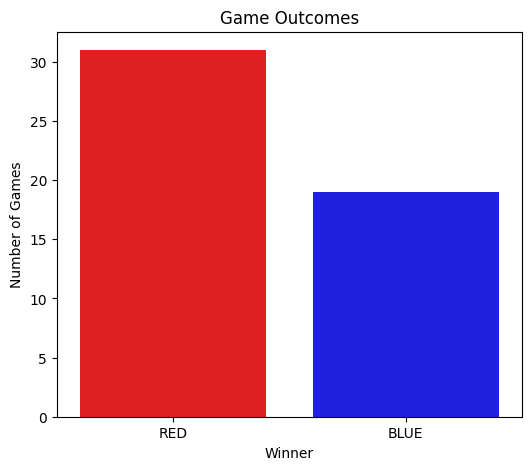

In [23]:
plt.figure(figsize=(6, 5))
sns.countplot(x='winner', data=df, palette={"RED": "red", "BLUE": "blue", "DRAW": "gray"})
plt.title('Game Outcomes')
plt.xlabel('Winner')
plt.ylabel('Number of Games')
plt.show()
